# AlexNet
## 网络架构
AlexNet 包含 8 层带权重的层：5 层卷积层和 3 层全连接层

## Features
相比于 LeNet，AlexNet 引入了以下几个决定性的新技术：

更深更大的网络：包含 5 个卷积层和 3 个全连接层。

ReLU 激活函数：替代了传统的 Sigmoid。ReLU 的计算更简单，且在正区间梯度恒为 1，有效缓解了梯度消失问题，让训练更深的网络成为可能。

Dropout 正则化：在全连接层中广泛使用 Dropout（随机丢弃一部分神经元），有效防止了模型在海量参数下的过拟合。

最大池化：LeNet 用的是平均池化，而 AlexNet 发现最大池化能更好地保留图像中最显著的特征（如边缘），同时让输出对位置微小的偏移更具鲁棒性。

数据增强：通过随机裁剪、翻转和改变亮度等方式，人为扩充了训练数据量，进一步防止过拟合。

## Frame
AlexNet 的输入是 $224 \times 224 \times 3$ 的彩色图像。整个网络分为两个主要部分：特征提取器（卷积层）和分类器（全连接层）

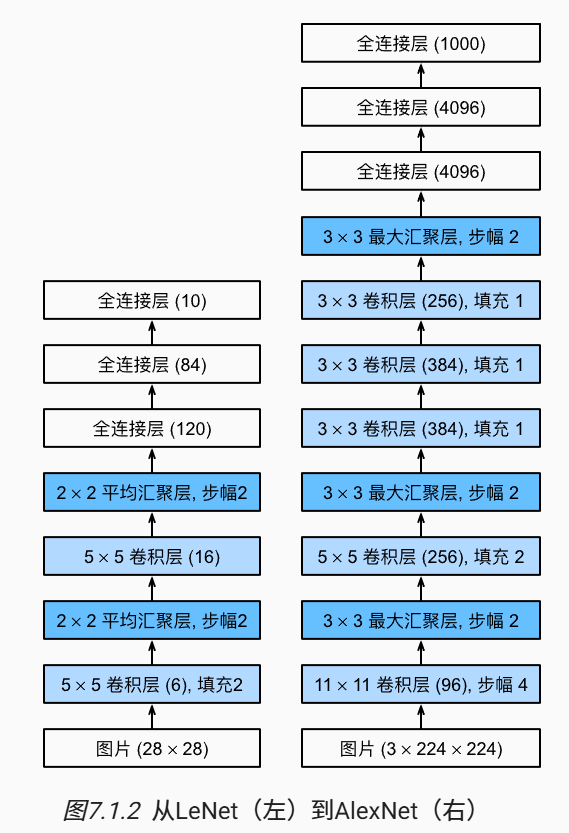

In [1]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import time

# 1. 定义网络结构
net = nn.Sequential(
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Flatten(),
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 10)
)

# 初始化权重
def init_weights(m):
    if type(m) == nn.Linear or type(m) == nn.Conv2d:
        nn.init.xavier_uniform_(m.weight)
net.apply(init_weights)

# 2. 数据准备：加载 Fashion-MNIST 并 Resize
batch_size = 128

# 定义数据预处理流程：先 Resize 到 224，再转为 Tensor
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor()
])

# 下载并加载训练集和测试集
train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, transform=transform, download=True)

train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 3. 定义评估函数 
def evaluate_accuracy(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval()  
        if not device:
            device = next(iter(net.parameters())).device
    
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            correct += (net(X).argmax(dim=1) == y).type(torch.float).sum().item()
            total += y.numel()
    return correct / total

# 4. 训练核心逻辑
def train_alexnet(net, train_iter, test_iter, num_epochs, lr, device):
    print(f'Training on {device}...')
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    
    for epoch in range(num_epochs):
        net.train() 
        train_loss_sum, train_acc_sum, n = 0.0, 0.0, 0
        start_time = time.time()
        
        for X, y in train_iter:
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            
            # 计算损失并反向传播
            loss = loss_fn(y_hat, y)
            loss.backward()
            optimizer.step()
            
            # 记录指标
            train_loss_sum += loss.item() * y.numel()
            train_acc_sum += (y_hat.argmax(dim=1) == y).type(torch.float).sum().item()
            n += y.numel()
            
        # 每个 epoch 结束后，评估测试集准确率
        test_acc = evaluate_accuracy(net, test_iter, device)
        epoch_time = time.time() - start_time
        
        print(f'Epoch {epoch + 1}/{num_epochs}: '
              f'Loss {train_loss_sum / n:.3f}, '
              f'Train Acc {train_acc_sum / n:.3f}, '
              f'Test Acc {test_acc:.3f}, '
              f'Time {epoch_time:.1f} sec')

# 5. 启动训练
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

lr, num_epochs = 0.01, 10
train_alexnet(net, train_iter, test_iter, num_epochs, lr, device)

Training on cuda...
Epoch 1/10: Loss 1.319, Train Acc 0.513, Test Acc 0.745, Time 37.4 sec
Epoch 2/10: Loss 0.642, Train Acc 0.761, Test Acc 0.799, Time 35.7 sec
Epoch 3/10: Loss 0.529, Train Acc 0.804, Test Acc 0.831, Time 35.2 sec
Epoch 4/10: Loss 0.468, Train Acc 0.829, Test Acc 0.841, Time 35.1 sec
Epoch 5/10: Loss 0.426, Train Acc 0.843, Test Acc 0.847, Time 35.9 sec
Epoch 6/10: Loss 0.400, Train Acc 0.854, Test Acc 0.854, Time 35.9 sec
Epoch 7/10: Loss 0.376, Train Acc 0.863, Test Acc 0.863, Time 35.1 sec
Epoch 8/10: Loss 0.358, Train Acc 0.871, Test Acc 0.877, Time 34.9 sec
Epoch 9/10: Loss 0.341, Train Acc 0.876, Test Acc 0.877, Time 35.6 sec
Epoch 10/10: Loss 0.329, Train Acc 0.880, Test Acc 0.882, Time 39.4 sec
